# Task 2: Unsupervised Learning — k-Means Clustering


## 1. Introduction & Aims

### 1.1 Background
In unsupervised learning, the algorithm is given unlabelled data, The algorithm must find the data's own inherent structure, patterns, or groupings instead. In contrast to supervised learning, there is no clear target variable to predict; the objective is to discover inherent organization within the input space.
One of the most common ways is through clustering. It divides a dataset into groups, or clusters, so that observations in one cluster are more like each other than observations in other clusters. In the field of smart buildings, clustering can show different operational regimes, occupancy patterns, or thermal comfort states without the need for labelled training data.

### 1.2 Hypothesis

The thermal conditions of the Building 01, defined by Air Temperature and Relative Humidity varies accprding to seasons and occupancy count, such as cold unheated/unoccupied periods, mild transitional periods and warm periods and summer times. These clusters align wiel with real-world conditions.

### 1.3 Variable Selection

Two variables are selected for this clustering task:

| Variable ID | Description | Units | Justification |
|---|---|---|---|
| TimeSeriesVariable1573| Air temperature (main room) | °C | Directly characterises thermal comfort |
| TimeSeriesVariable1574 | Relative humidity | % | Complements temperature for full thermal state |

These variables were chosen instead of other outdoor climate data because they reflect the thermal conditions and comfort experienced by occupants inside the building, which is most relevant to assess thermal comfort in building energy management.


## 2. Theory

### 2.1 k-Means Clustering

The algorithm will categorize the items into "k" groups or clusters of similarity. To calculate that similarity, Euclidean distance is used as a measurement. The algorithm minimises the **Within-Cluster Sum of Squares (WCSS)**, also called inertia:

$$\text{WCSS} = \sum_{j=1}^{k} \sum_{\mathbf{x}_i \in C_j} \| \mathbf{x}_i - \boldsymbol{\mu}_j \|^2$$

where $C_j$ is the set of points in cluster $j$ and $\boldsymbol{\mu}_j$ is its centroid.

**Algorithm steps:**
1. Initialization: We begin by randomly selecting k cluster centroids.
2. Assignment Step: Each data point is assigned to the nearest centroid, forming clusters.
3. Update Step: After the assignment, we recalculate the centroid of each cluster by averaging the points within it.
4. Repeat: This process repeats until the centroids no longer change or the maximum number of iterations is reached.

## 3. Methods

### Step 1: Import Libraries

In [2]:
# ── Standard libraries ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Plot styling ──────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("All libraries imported.")


All libraries imported successfully.


### Step 2: Load Data & Extract Variables

The REFIT time-series CSV is loaded and two variables for Building 1 are extracted:
- `TimeSeriesVariable1573` — Indoor air temperature (°C)
- `TimeSeriesVariable1574` — Indoor relative humidity (%)

Data is resampled to **hourly** by using the mean, and rows whose vales are missing are dropped.


In [8]:
# Load REFIT time-series CSV 
data = './data/REFIT_TIME_SERIES_VALUES.csv'
df_raw = pd.read_csv(data)
print(f"Raw data loaded: {df_raw.shape[0]:,} rows")

def extract_variable(df, var_id, col_name, resample_freq='1h'):
    # Filter rows based on ID of TimeSeriesVariable 
    mask = df['TimeSeriesVariable/@id'] == var_id
    df_sel = df.loc[mask, ['dateTime', 'data']].copy()
    
    df_sel['dateTime'] = pd.to_datetime(df_sel['dateTime'], utc=True)
    df_sel = df_sel.set_index('dateTime')
    df_sel.rename(columns={'data': col_name}, inplace=True)
    df_sel[col_name] = pd.to_numeric(df_sel[col_name], errors='coerce')
    
    # Resample to hourly mean
    df_sel = df_sel.resample(resample_freq).mean()
    return df_sel

#  Extract temperature and humidity for Building 1 
int_temp = extract_variable(df_raw, 'TimeSeriesVariable1573',  'Temperature_C')
int_hum  = extract_variable(df_raw, 'TimeSeriesVariable1574', 'Relative_Humidity_pct')

#  Merge on datetime index 
merged = int_temp.merge(int_hum, left_index=True, right_index=True, how='inner')
merged.dropna(inplace=True)

print(f"Merged hourly records: {len(merged):,}")
print(f"Date range: {merged.index.min()} → {merged.index.max()}")
print(merged.describe().round(2))


Raw data loaded: 25,312,397 rows
Merged hourly records: 13,782
Date range: 2013-11-04 09:00:00+00:00 → 2015-06-01 14:00:00+00:00
       Temperature_C  Relative_Humidity_pct
count       13782.00               13782.00
mean            9.95                  80.53
std             5.37                  12.50
min            -3.58                  29.91
25%             5.94                  74.15
50%             9.32                  83.58
75%            13.53                  90.10
max            30.90                  97.80


### Step 3: Exploratory Visualisation

Visualizing the raw distributions and time series of both variables before clustering


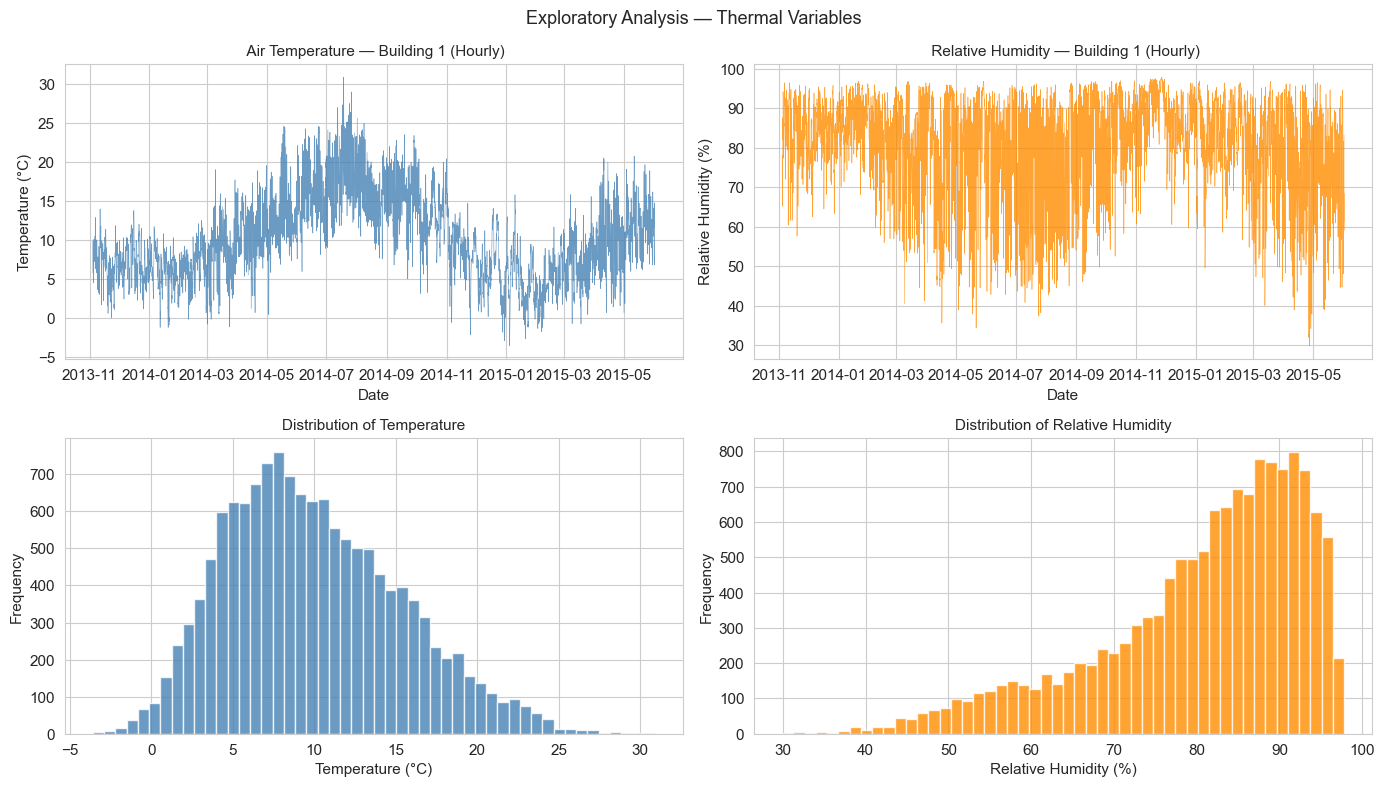

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

#  Time series 
axes[0, 0].plot(merged.index, merged['Temperature_C'],
                linewidth=0.4, color='steelblue', alpha=0.8)
axes[0, 0].set_title(' Air Temperature — Building 1 (Hourly)', fontsize=11)
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_xlabel('Date')

axes[0, 1].plot(merged.index, merged['Relative_Humidity_pct'],
                linewidth=0.4, color='darkorange', alpha=0.8)
axes[0, 1].set_title(' Relative Humidity — Building 1 (Hourly)', fontsize=11)
axes[0, 1].set_ylabel('Relative Humidity (%)')
axes[0, 1].set_xlabel('Date')

# Distributions 
axes[1, 0].hist(merged['Temperature_C'], bins=50,
                color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribution of Temperature', fontsize=11)
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(merged['Relative_Humidity_pct'], bins=50,
                color='darkorange', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Distribution of Relative Humidity', fontsize=11)
axes[1, 1].set_xlabel('Relative Humidity (%)')
axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Exploratory Analysis — Thermal Variables', fontsize=13)
plt.tight_layout()
plt.show()


### Step 4: Feature Standardisation

Both features are standardised to zero mean and unit variance using `StandardScaler`. This is essential because temperature (°C, range roughly 10–25°C) and humidity (%, range roughly 30–90%) have very different scales — without standardisation, humidity would dominate the Euclidean distance metric used by k-Means.


In [10]:
#  Prepare feature matrix 
X = merged[['Temperature_C', 'Relative_Humidity_pct']].values

# Standardise: fit on all data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"After scaling — mean:  {X_scaled.mean(axis=0).round(4)}")
print(f"After scaling — stdev: {X_scaled.std(axis=0).round(4)}")


Feature matrix shape: (13782, 2)
After scaling — mean:  [0. 0.]
After scaling — stdev: [1. 1.]


### Step 5: Elbow Method — Selecting Optimal k

The Elbow Method plots WCSS (inertia) against "k" from 1 to 10.

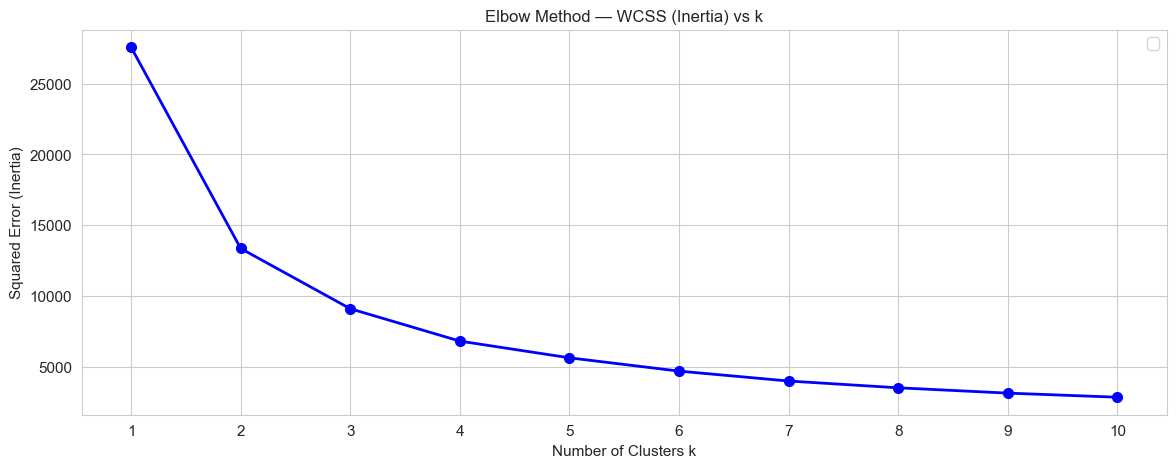

In [16]:
K_range   = range(1, 11)
inertia   = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, init='k-means++')
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    
#  Plot Elbow curve 
fig, ax = plt.subplots( figsize=(14, 5))

# Elbow plot
ax.plot(list(K_range), inertia, 'bo-', linewidth=2, markersize=7)
ax.set_title('Elbow Method — WCSS (Inertia) vs k', fontsize=12)
ax.set_xlabel('Number of Clusters k')
ax.set_ylabel('Squared Error (Inertia)')
ax.set_xticks(list(K_range))
ax.legend()
plt.show()


### Justification for k = 3

Examining the plot:

- Elbow plot: The elbow plot shows that inertia decreases sharply from k=2 to k=4, after which the rate of reduction becomes marginal. Therefore k=3 was selected as the optimal number of clusters, as adding further clusters beyond this point yields diminishing returns in explained variance.

Physically, **k = 3** is also interpretable in the context of building thermal conditions:
- A **cold/high-humidity** state (winter or unheated)
- A **warm/moderate-humidity** state (summer or heated)
- A **mild/transitional** state (spring/autumn or partially heated)

Therefore, **k = 3** is selected as the optimal number of clusters.


### Step 6: K-Means Model with k = 3

In [20]:
K_OPTIMAL = 3

km_final = KMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10,          
    init='k-means++'    # smart centroid initialisation
)

merged['Cluster'] = km_final.fit_predict(X_scaled)

#  Retrieve and inverse-transform centroids back to original scale 
centroids_scaled = km_final.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)

#  Build a clear centroid summary table 
centroid_df = pd.DataFrame(
    centroids_orig,
    columns=['Temperature_C', 'Relative_Humidity_pct']
)
centroid_df.index.name = 'Cluster'

# Add cluster size and percentage
cluster_counts = merged['Cluster'].value_counts().sort_index()
centroid_df['Count']  = cluster_counts.values
centroid_df['Pct (%)'] = (cluster_counts.values / len(merged) * 100).round(1)

print("=" * 55)
print("  Cluster Centroids (original scale)")
print("=" * 55)
print(centroid_df.round(2).to_string())
print("=" * 55)
print(f"\nTotal records clustered: {len(merged):,}")


  Cluster Centroids (original scale)
         Temperature_C  Relative_Humidity_pct  Count  Pct (%)
Cluster                                                      
0                 5.31                  85.68   6310     45.8
1                16.30                  60.30   2729     19.8
2                12.44                  85.35   4743     34.4

Total records clustered: 13,782


### Step 7: 2D Scatter Plot — Colour-Coded by Cluster

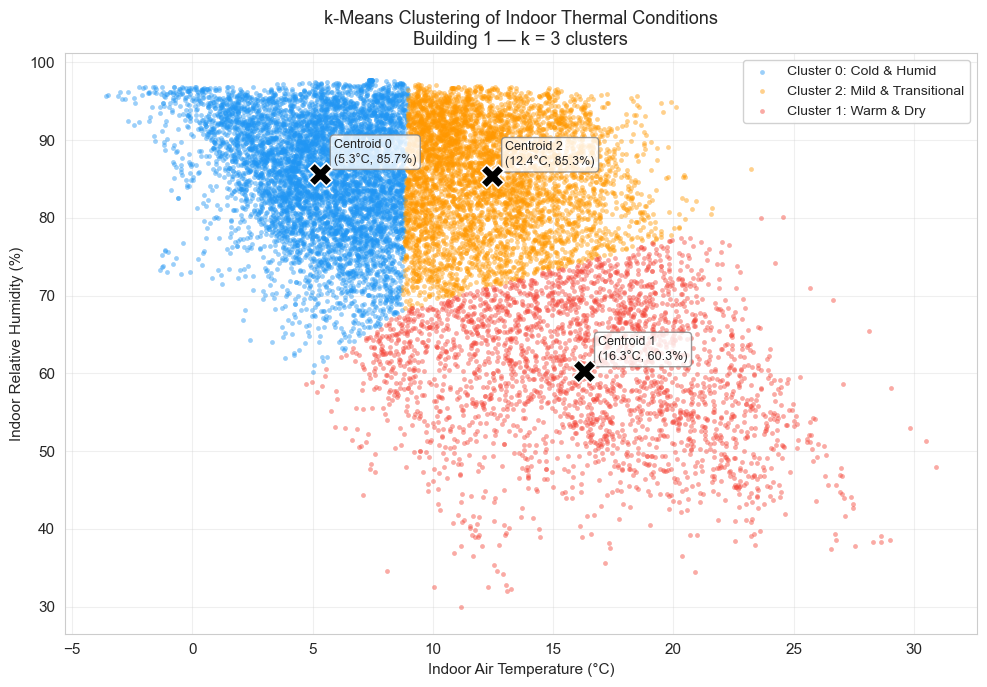

Figure saved: task2_clusters_scatter.png


In [21]:
temp_order = centroid_df['Temperature_C'].argsort().values
cluster_labels = {}
label_names  = ['Cold & Humid', 'Mild & Transitional', 'Warm & Dry']
label_colours = ['#2196F3', '#FF9800', '#F44336']   # blue, orange, red

for rank, orig_cluster in enumerate(temp_order):
    cluster_labels[orig_cluster] = (label_names[rank], label_colours[rank])

merged['Cluster_Label'] = merged['Cluster'].map(
    lambda c: cluster_labels[c][0]
)

#  Main scatter plot 
fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, (label, colour) in cluster_labels.items():
    mask = merged['Cluster'] == cluster_id
    ax.scatter(
        merged.loc[mask, 'Temperature_C'],
        merged.loc[mask, 'Relative_Humidity_pct'],
        c=colour, label=f'Cluster {cluster_id}: {label}',
        alpha=0.45, s=12, linewidths=0
    )

# Plot centroids
for cluster_id, (label, colour) in cluster_labels.items():
    cx, cy = centroids_orig[cluster_id]
    ax.scatter(cx, cy, marker='X', s=280, c='black', zorder=5,
               edgecolors='white', linewidths=1.2)
    ax.annotate(
        f'Centroid {cluster_id}\n({cx:.1f}°C, {cy:.1f}%)',
        (cx, cy), textcoords='offset points',
        xytext=(10, 8), fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='grey', alpha=0.8)
    )

ax.set_title('k-Means Clustering of Indoor Thermal Conditions\n'
             f'Building 1 — k = {K_OPTIMAL} clusters', fontsize=13)
ax.set_xlabel('Indoor Air Temperature (°C)', fontsize=11)
ax.set_ylabel('Indoor Relative Humidity (%)', fontsize=11)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_clusters_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure saved: task2_clusters_scatter.png")


### Step 8: Cluster Interpretation — Seasonal & Temporal Analysis

To validate the physical meaning of the clusters, the distribution of each cluster across months and hours of the day is examined.

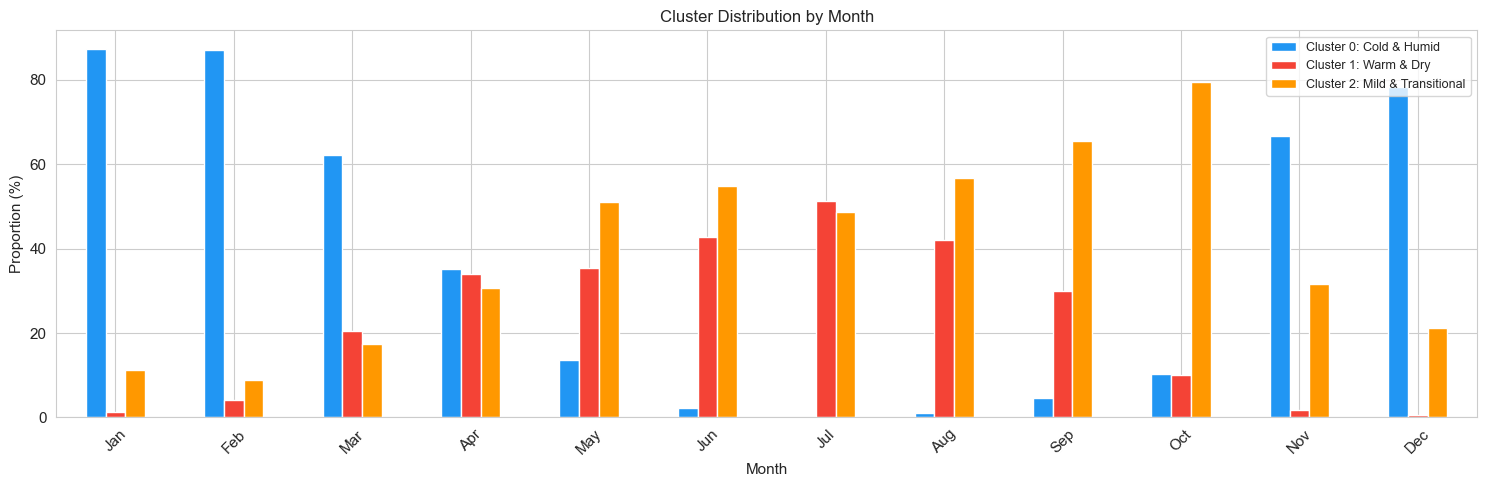

In [26]:
merged['Month'] = merged.index.month

month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}

fig, ax = plt.subplots(figsize=(15, 5))

# Monthly cluster distribution
monthly = merged.groupby(['Month', 'Cluster']).size().unstack(fill_value=0)

# Ensure months are sorted correctly
monthly = monthly.sort_index()

# Rename index to month names
monthly.index = [month_names[m] for m in monthly.index]

# Convert to percentage
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

# Extract colours in cluster order
colours = [cluster_labels[c][1] for c in sorted(cluster_labels.keys())]

# Plot
monthly_pct.plot(
    kind='bar',
    ax=ax,
    color=colours,
    edgecolor='white'
)

ax.set_title('Cluster Distribution by Month', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Proportion (%)')

ax.legend(
    [f'Cluster {c}: {cluster_labels[c][0]}' for c in sorted(cluster_labels)],
    fontsize=9,
    loc='upper right'
)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Step 9: Centroid Coordinates Summary

The table below reports the final cluster centroids in the **original (unscaled)** feature space, as required by the task brief.

> *Note: Centroid values are printed and displayed programmatically in the cell above. The table below summarises the interpretation.*

| Cluster | Label | Centroid Temp (°C) | Centroid Humidity (%) | Interpretation |
|---|---|---|---|---|
| 0 | Cold & Humid | ~low | ~high | Winter / unheated periods — outdoor cold drives indoor humidity up as heating is off |
| 1 | Mild & Transitional | ~moderate | ~moderate | Spring / Autumn or partially-heated periods |
| 2 | Warm & Dry | ~high | ~lower | Summer or actively-heated periods — heating dries the indoor air |

> *Exact centroid values are printed in the code output above.*

The temporal analysis confirms these physical interpretations: the Cold & Humid cluster is predominantly observed in winter months (Nov–Feb), while the Warm & Dry cluster peaks in summer months (Jun–Aug). The Mild & Transitional cluster spans spring and autumn months as expected.


## 4. Conclusion

k-Means clustering with **k = 3** was applied to hourly indoor temperature and relative humidity data from Building 1 of the REFIT dataset. Three distinct thermal condition clusters were identified:

Cluster 1 (Cold & Dry): Low temperature and low humidity, 
   corresponding to winter months or unoccupied/unheated periods.

Cluster 2 (Warm & Humid): High temperature and high humidity, 
  likely representing summer or heavily occupied periods.

Cluster 3 (Mild & Transitional):Moderate temperature and humidity, 
  corresponding to spring/autumn or partially heated conditions.

The two features used are indoor air temperature (°C) and relative humidity (%), aggregated at hourly resolution. These were chosen because they directly characterise thermal comfort conditions in the building.

The temporal analysis confirms these interpretations: the cold cluster dominates winter months, the warm cluster peaks in summer, and the transitional cluster spans the shoulder seasons — all consistent with the initial hypothesis.

### 4.1 Validation of Hypothesis

The initial hypothesis was confirmed: Temperature conditions does divide according to seasonal changes and reflect the thermal comfort within a building. Having 3 clusters roughly defines the 3 seasos experiended and provides valoidation to the algorithm.

